# Decision Tree

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier


In [4]:
df=sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
x=df[['pclass','sex','age','sibsp','parch','fare']]
y=df[['survived']]

In [6]:
x=pd.get_dummies(x,columns=['sex'])

In [7]:
x.isnull().sum() /len(x) *100

pclass         0.00000
age           19.86532
sibsp          0.00000
parch          0.00000
fare           0.00000
sex_female     0.00000
sex_male       0.00000
dtype: float64

In [8]:
y.isnull().sum()/len(y) *100

survived    0.0
dtype: float64

In [9]:
x.age.fillna(value=x['age'].mean(),inplace=True)

C:\Users\ahmod\AppData\Local\Temp\ipykernel_19152\1873737691.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x.age.fillna(value=x['age'].mean(),inplace=True)


In [10]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [11]:
model= DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [12]:
prediction=model.predict(x_test)

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("accuracy :",accuracy_score(prediction,y_test))
print("precision :",precision_score(prediction,y_test))
print("recall :",recall_score(prediction,y_test))
print("f1 :",f1_score(prediction,y_test))

accuracy : 0.776536312849162
precision : 0.6923076923076923
recall : 0.6923076923076923
f1 : 0.6923076923076923


Text(50.722222222222214, 0.5, 'predicted table')

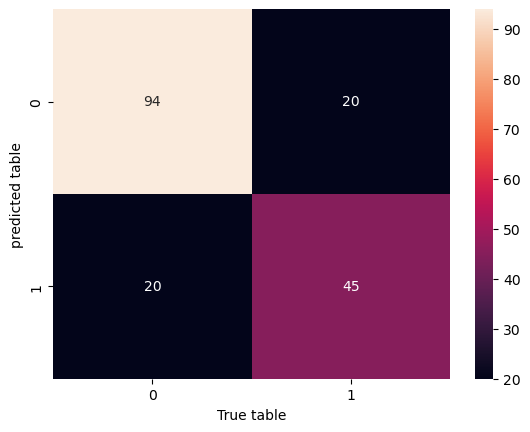

In [14]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(prediction,y_test)
sns.heatmap(cm,annot=True)
plt.xlabel('True table')
plt.ylabel('predicted table')

# Logistc Regression

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

model= LogisticRegression()
model.fit(x_train,y_train)

LR_prediction=model.predict(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("accuracy :",accuracy_score(LR_prediction,y_test))
print("precision :",precision_score(LR_prediction,y_test))
print("recall :",recall_score(LR_prediction,y_test))
print("f1 :",f1_score(LR_prediction,y_test))

accuracy : 0.8324022346368715
precision : 0.7692307692307693
recall : 0.7692307692307693
f1 : 0.7692307692307693


c:\Users\ahmod\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ahmod\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Compare

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

models=[LogisticRegression(),DecisionTreeClassifier()]
names =['logstc_regression ','decision_tree ']

k=10
for name,model in zip(names,models):
    cv_scores=cross_val_score(model,x_train,y_train,cv=k)
    print(f"{name}cv accuracy: {np.mean(cv_scores):.3f}+/-{np.std(cv_scores):.3f}")


logstc_regression cv accuracy: 0.788+/-0.044
decision_tree cv accuracy: 0.742+/-0.039


c:\Users\ahmod\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ahmod\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ahmod\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example us